In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)


# NORMAL (GAUSSIAN) DISTRIBUTION
📌 What it looks like

Bell-shaped

Symmetric

📌 Why it’s good

Mean ≈ Median ≈ Mode

Works perfectly with linear models

📌 Problem

Almost no problem (ideal case)

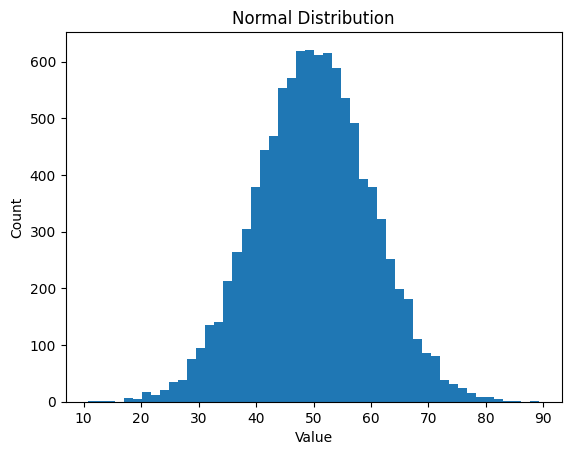

In [3]:
normal_data = np.random.normal(loc=50, scale=10, size=10000)

plt.hist(normal_data, bins=50)
plt.title("Normal Distribution")
plt.xlabel("Value")
plt.ylabel("Count")
plt.show()


# RIGHT-SKEWED (POSITIVE SKEW)
📌 What it looks like

Long tail on the right

📌 What it says

Few very large values (outliers)

Mean is misleading

📌 Real-world examples

Income

Ratings with errors

House prices

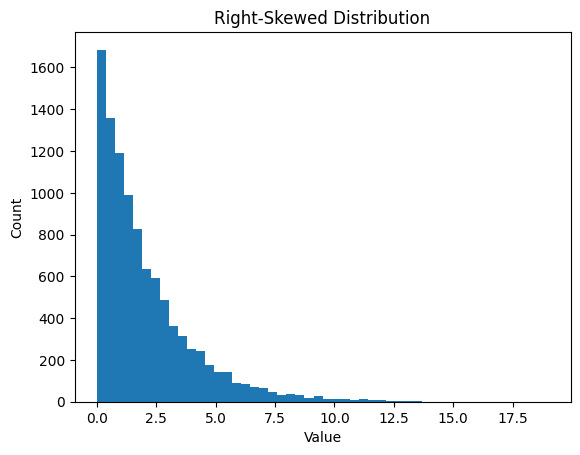

In [4]:
right_skewed = np.random.exponential(scale=2, size=10000)

plt.hist(right_skewed, bins=50)
plt.title("Right-Skewed Distribution")
plt.xlabel("Value")
plt.ylabel("Count")
plt.show()


❌ Problems

Mean inflated

Linear regression breaks

Distance-based models suffer

✅ Fix: Log Transform

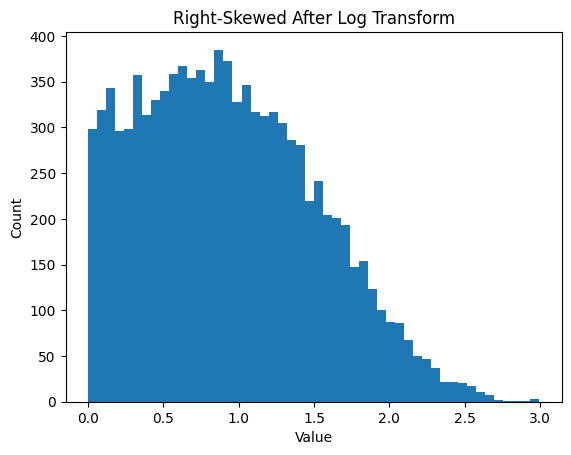

In [5]:
log_fixed = np.log1p(right_skewed)

plt.hist(log_fixed, bins=50)
plt.title("Right-Skewed After Log Transform")
plt.xlabel("Value")
plt.ylabel("Count")
plt.show()


# LEFT-SKEWED (NEGATIVE SKEW)
📌 What it looks like

Long tail on the left

📌 What it says

Most values are high

Poor performers are rare

📌 Examples

Exam scores

Customer satisfaction

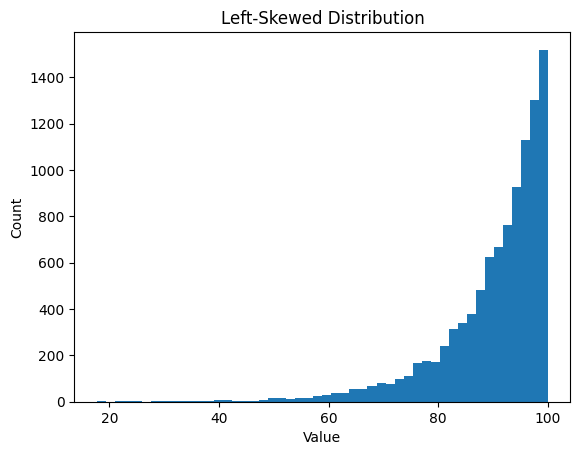

In [6]:
left_skewed = 100 - np.random.exponential(scale=10, size=10000)

plt.hist(left_skewed, bins=50)
plt.title("Left-Skewed Distribution")
plt.xlabel("Value")
plt.ylabel("Count")
plt.show()


❌ Problem

Mean underestimates actual performance

✅ Fix: Power Transform

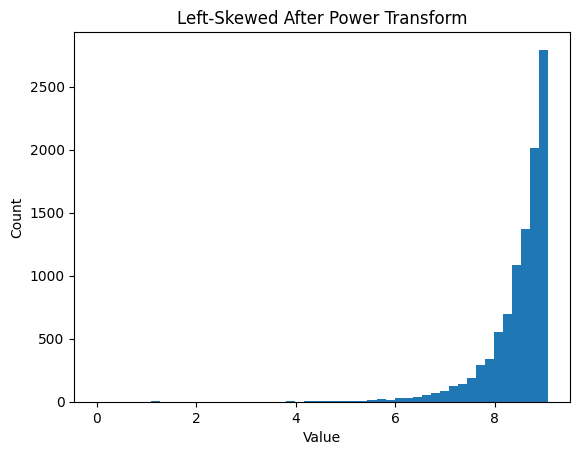

In [7]:
power_fixed = np.sqrt(left_skewed - left_skewed.min())

plt.hist(power_fixed, bins=50)
plt.title("Left-Skewed After Power Transform")
plt.xlabel("Value")
plt.ylabel("Count")
plt.show()


# UNIFORM DISTRIBUTION
📌 What it looks like

Flat

No peaks

📌 What it says

No dominant value

Weak predictive power

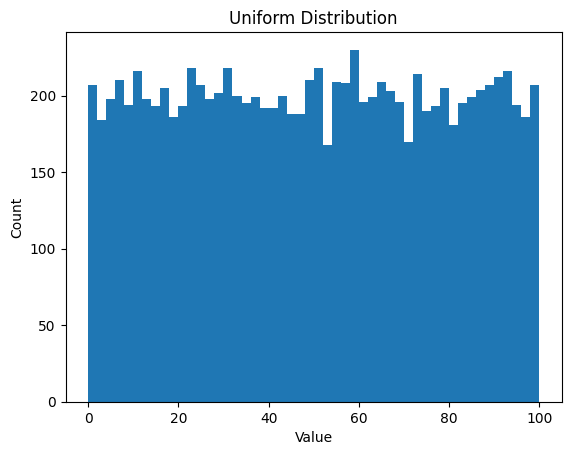

In [8]:
uniform_data = np.random.uniform(low=0, high=100, size=10000)

plt.hist(uniform_data, bins=50)
plt.title("Uniform Distribution")
plt.xlabel("Value")
plt.ylabel("Count")
plt.show()


❌ Problem: No useful signal
✅ Fix: Often drop the feature

# BIMODAL DISTRIBUTION
📌 What it looks like

Two peaks

📌 What it says

Two different populations mixed

📌 Examples

Beginner vs expert users

Male vs female heights

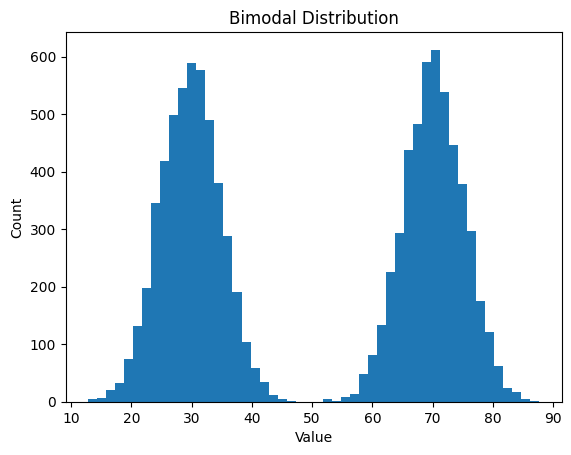

In [9]:
bimodal = np.concatenate([
    np.random.normal(30, 5, 5000),
    np.random.normal(70, 5, 5000)
])

plt.hist(bimodal, bins=50)
plt.title("Bimodal Distribution")
plt.xlabel("Value")
plt.ylabel("Count")
plt.show()


❌ Problem

Single model struggles

✅ Fix

Segment data

Create category feature

Clustering before modeling

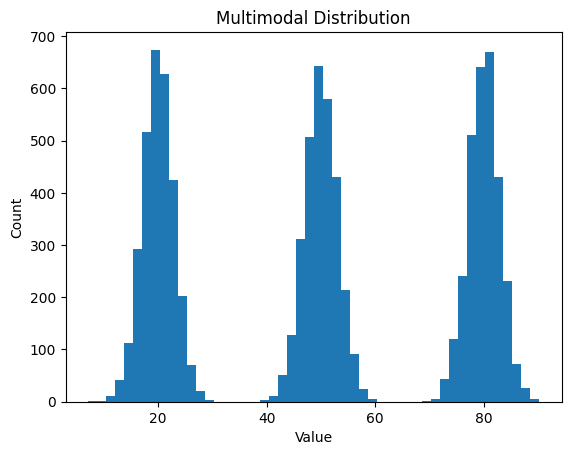

In [10]:
multi_modal = np.concatenate([
    np.random.normal(20, 3, 3000),
    np.random.normal(50, 3, 3000),
    np.random.normal(80, 3, 3000)
])

plt.hist(multi_modal, bins=50)
plt.title("Multimodal Distribution")
plt.xlabel("Value")
plt.ylabel("Count")
plt.show()


# OUTLIERS (IMPORTANT)
📌 What it looks like

Points far from main cluster

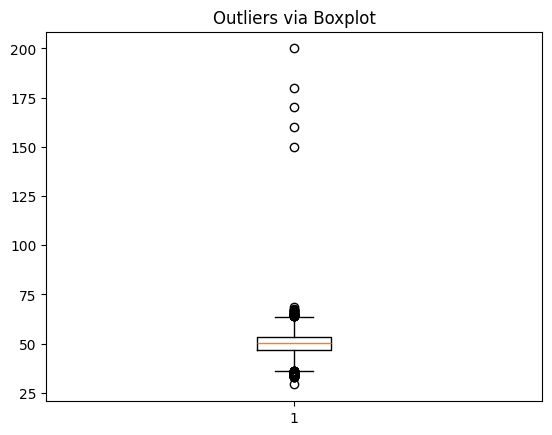

In [11]:
data_with_outliers = np.concatenate([
    np.random.normal(50, 5, 9800),
    np.array([150, 160, 170, 180, 200])
])

plt.boxplot(data_with_outliers)
plt.title("Outliers via Boxplot")
plt.show()


❌ Problems

Mean distorted

MSE explodes

KNN / SVM fail

✅ Fix 1: Remove

In [12]:
q1 = np.percentile(data_with_outliers, 25)
q3 = np.percentile(data_with_outliers, 75)
iqr = q3 - q1

cleaned = data_with_outliers[
    (data_with_outliers >= q1 - 1.5 * iqr) &
    (data_with_outliers <= q3 + 1.5 * iqr)
]


✅ Fix 2: Cap (Winsorization)

In [13]:
capped = np.clip(data_with_outliers, q1, q3)


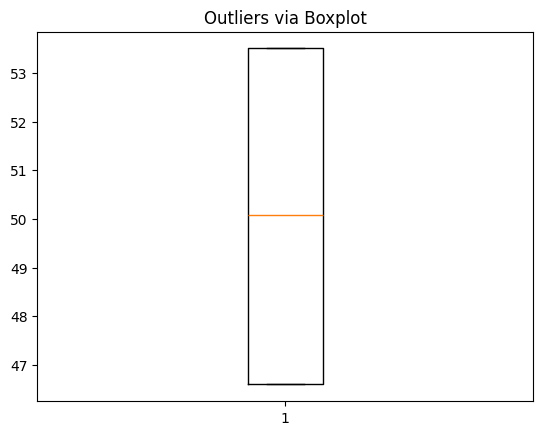

In [16]:
plt.boxplot(capped)
plt.title("Outliers via Boxplot")
plt.show()

# LONG-TAILED DISTRIBUTION
📌 What it says

Rare events are important

Do NOT remove blindly

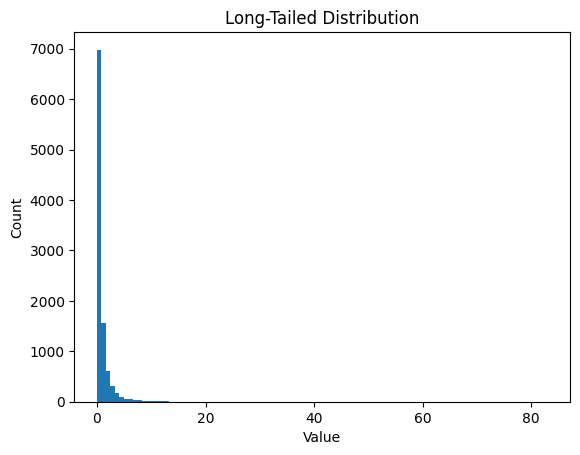

In [14]:
long_tail = np.random.pareto(a=2, size=10000)

plt.hist(long_tail, bins=100)
plt.title("Long-Tailed Distribution")
plt.xlabel("Value")
plt.ylabel("Count")
plt.show()


✅ Fix:

Log transform

Tree-based models

## 📌 Final Summary Table (Mental Model for EDA & Feature Engineering)

| Distribution   | Meaning              | Problem                         | Fix / Action        |
|---------------|----------------------|---------------------------------|---------------------|
| Normal        | Ideal distribution   | None                            | None                |
| Right-skewed  | Few large values     | Mean inflated                   | Log transform       |
| Left-skewed   | Few small values     | Mean misleading                 | Power transform     |
| Uniform       | No signal            | Useless feature                 | Drop feature        |
| Bimodal       | Mixed groups         | Poor single-model fit           | Segment / cluster   |
| Outliers      | Errors or rare cases | Model breaks / high loss        | Remove or cap       |
| Long-tailed   | Rare but important   | Bias in mean-based models       | Log + tree models   |
